# Worksheet 8 - Neural networks II

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from sklearn.metrics import r2_score

## 1 - Data

In [2]:
spectra = np.load('spectra.npy')
labels = pd.read_csv('labels_table.csv', index_col=0) # after visual insepction the table showed an unnamed index column --> index_col=0
auxiliary = pd.read_csv('auxiliary_table.csv')

In [3]:
labels

,planet_ID,planet_radius,planet_temp,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
0,train1,0.559620,863.394770,-8.865868,-6.700707,-5.557561,-8.957615,-3.097540
1,train2,1.118308,1201.700465,-4.510258,-8.228966,-3.565427,-7.807424,-3.633658
2,train3,0.400881,1556.096477,-7.225472,-6.931472,-3.081975,-8.567854,-5.378472
3,train4,0.345974,1268.624884,-7.461157,-5.853334,-3.044711,-5.149378,-3.815568
4,train5,0.733184,1707.323564,-4.140844,-7.460278,-3.181793,-5.996593,-4.535345
...,...,...,...,...,...,...,...,...
41418,train41419,1.430950,1167.563319,-7.556565,-7.075889,-4.735715,-7.532563,-7.854443
41419,train41420,0.277752,649.703932,-7.434332,-7.161510,-5.274940,-4.100312,-3.651804
41420,train41421,0.136016,1445.371723,-5.525906,-5.079240,-4.945121,-5.787630,-8.015444
41421,train41422,0.707851,653.284686,-4.616695,-8.782546,-3.767229,-3.221403,-8.427805


In [4]:
auxiliary

,planet_ID,star_distance,star_mass_kg,star_radius_m,star_temperature,planet_mass_kg,planet_orbital_period,planet_distance,planet_surface_gravity
0,train1,530.7650,1.968526e+30,6.678720e+08,5636.0,3.990923e+26,9.668577,0.088530,16.642039
1,train2,440.0890,1.948642e+30,7.235280e+08,5449.0,4.977001e+26,4.218028,0.050752,5.197135
2,train3,1126.3700,2.147483e+30,7.791840e+08,5675.0,9.686804e+25,2.828042,0.040158,7.871718
3,train4,1257.1600,2.048062e+30,7.374420e+08,5849.0,4.486340e+25,3.855604,0.048601,4.894681
4,train5,211.5530,2.525281e+30,1.092249e+09,6200.0,2.416329e+26,3.076340,0.044833,5.870151
...,...,...,...,...,...,...,...,...,...
41418,train41419,703.3020,1.988410e+30,7.722270e+08,5821.0,7.125924e+26,5.370647,0.060024,4.544766
41419,train41420,72.7998,1.292466e+30,4.035060e+08,4258.0,7.709155e+25,6.342000,0.058089,13.050003
41420,train41421,1786.4800,1.789569e+30,7.096140e+08,6002.0,2.794853e+25,3.546511,0.043946,19.728779
41421,train41422,329.0410,1.849221e+30,6.748290e+08,5519.0,1.400242e+26,22.631964,0.152856,3.649544


## 2 - Data visualisation

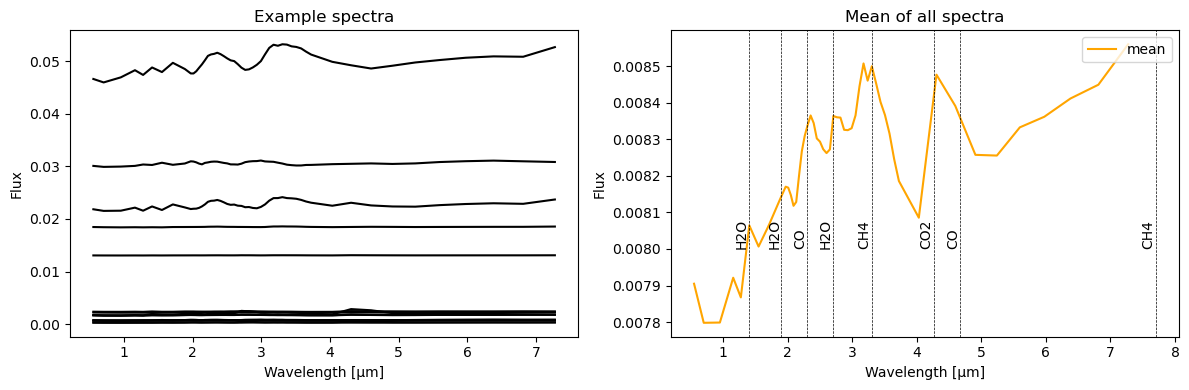

In [75]:
random = np.random.randint(0, 41423, size=15)
mean_spectrum = spectra[:, :, 1].mean(axis=0)

emission_lines = {
    'H2O': [1.4, 1.9, 2.7],
    'CO2': [4.26],
    'CO': [2.3, 4.67],
    'CH4': [3.3, 7.7],
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for i in random:
    ax1.plot(spectra[i,:,0], spectra[i, :, 1], color='black')

ax1.set_xlabel('Wavelength [μm]')
ax1.set_ylabel('Flux')
ax1.set_title('Example spectra')

ax2.plot(spectra[0,:,0], mean_spectrum, color='orange', label='mean')
ax2.set_xlabel('Wavelength [μm]')
ax2.set_ylabel('Flux')
ax2.set_title('Mean of all spectra')

for molecule, wavelengths in emission_lines.items():
    for w in wavelengths:
        ax2.axvline(x=w, linewidth=0.5, color='black', linestyle='--')
        ax2.text(w, 0.008, molecule, rotation=90, verticalalignment='bottom', horizontalalignment='right')

plt.tight_layout()
plt.legend(loc='upper right')
plt.show()

## 3 - Convolutional Neural Network (CNN)

### Prepare the data:

**Logarithmic transformation of the auxiliary data:**

In [6]:
aux = pd.DataFrame({
    'log_star_distance': np.log10(auxiliary['star_distance']),
    'log_star_mass':     np.log10(auxiliary['star_mass_kg']),
    'log_star_radius':   np.log10(auxiliary['star_radius_m']),
    'star_temperature':  auxiliary['star_temperature'], # no transformation for temperature
    'log_planet_mass':   np.log10(auxiliary['planet_mass_kg']),
    'log_orbital_period':np.log10(auxiliary['planet_orbital_period']),
    'log_planet_dist':   np.log10(auxiliary['planet_distance']),
    'log_surface_grav':  np.log10(auxiliary['planet_surface_gravity']),
})

**Create two input datasets: X (without auxiliary data) and X_aux (the auxiliary data):**

In [7]:
X = spectra[:,:,1]
X_aux = aux.to_numpy()
y = labels.select_dtypes(include=['float64', 'int64']).to_numpy()

**Split data into training, validation and test data (80/10/10):**

The spectra are the input data X, the labels (the planets properties) are the targets y. The auxiliary data are additional inputs that should lead to better predictions and will be included later, but are already taken into account at this point, so that the data split is the same for all models.

In [ ]:
# split 80/20
X_train, X_temp, X_aux_train, X_aux_temp, y_train, y_temp = train_test_split(X, X_aux, y, test_size=0.20, random_state=42)

# split again into test and validation sample (10/10)
X_val, X_test, X_aux_val, X_aux_test, y_val, y_test = train_test_split(X_temp, X_aux_temp, y_temp, test_size=0.50, random_state=42)


print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

print(X_aux_train.shape)
print(X_aux_val.shape)
print(X_aux_test.shape)


(33138, 52)
(4142, 52)
(4143, 52)
(33138, 8)
(4142, 8)
(4143, 8)


**Scale all the data to reach better results from the models:**

In [9]:
X_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train)
X_val   = X_scaler.transform(X_val)
X_test  = X_scaler.transform(X_test)

aux_scaler = StandardScaler()
X_aux_train = aux_scaler.fit_transform(X_aux_train)
X_aux_val   = aux_scaler.transform(X_aux_val)
X_aux_test  = aux_scaler.transform(X_aux_test)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train)
y_val   = y_scaler.transform(y_val)
y_test  = y_scaler.transform(y_test)


**Reshape the input data and add a new dimension:**

The CNN expects (samples, sequence_length, channels), but right now X does not contain the channel column:

In [10]:
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(33138, 52, 1)
(4142, 52, 1)
(4143, 52, 1)


### Build the models:

**Fit a convolutional network model to the training and validation data for both X and X_aux:**

In [11]:
# model for spectra alone as input:

model = models.Sequential()
model.add(layers.Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(52,1)))
model.add(layers.MaxPooling1D(pool_size=2))
model.add(layers.Conv1D(filters=64, kernel_size=3, activation='relu',))
model.add(layers.MaxPooling1D(pool_size=2))
model.add(layers.Flatten())
model.add(layers.Dense(units=64, activation='relu'))
model.add(layers.Dense(y_train.shape[1]))

c:\Users\helen\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# inputs for the second model:

spectrum_input = tf.keras.Input(shape=(52,1), name='spectrum')
aux_input = tf.keras.Input(shape=(8,), name='auxiliary')

# spectral features

x = layers.Conv1D(filters=32, kernel_size=3, activation='relu')(spectrum_input)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.Conv1D(filters=64, kernel_size=3, activation='relu')(x)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.Flatten()(x)

# auxiliary data

a = layers.Dense(units=16, activation='relu')(aux_input)
a = layers.Dense(units=16, activation='relu')(a)

# combine the branches for the whole model and put the model together

combined = layers.Concatenate()([x, a])

z = layers.Dense(units=64, activation='relu')(combined)
output = layers.Dense(units=y_train.shape[1])(z)

model_aux = tf.keras.Model(inputs=[spectrum_input, aux_input], outputs=output)

**Compile the models:**

In [14]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_aux.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [15]:
model.summary()
model_aux.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 23, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 704)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,911 (202.78 KB)

 Trainable params: 51,911 (202.78 KB)

 Non-trainable params: 0 (0.00 B)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ spectrum            │ (None, 52, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 50, 32)    │        128 │ spectrum[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 25, 32)    │          0 │ conv1d_4[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 23, 64)    │      6,208 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ auxiliary           │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 11, 64)    │          0 │ conv1d_5[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        144 │ auxiliary[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 704)       │          0 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        272 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 720)       │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │     46,144 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 7)         │        455 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 53,351 (208.40 KB)

 Trainable params: 53,351 (208.40 KB)

 Non-trainable params: 0 (0.00 B)

**Train the model:**

In [16]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200, batch_size=64, verbose=1)

Epoch 1/200
518/518 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.8711 - mae: 0.7667 - val_loss: 0.8216 - val_mae: 0.7384
Epoch 2/200
518/518 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.7447 - mae: 0.6977 - val_loss: 0.6543 - val_mae: 0.6473
Epoch 3/200
518/518 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5762 - mae: 0.5966 - val_loss: 0.5127 - val_mae: 0.5515
Epoch 4/200
518/518 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4734 - mae: 0.5295 - val_loss: 0.4400 - val_mae: 0.5089
Epoch 5/200
518/518 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4181 - mae: 0.4917 - val_loss: 0.3894 - val_mae: 0.4691
Epoch 6/200
518/518 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3777 - mae: 0.4630 - val_loss: 0.3635 - val_mae: 0.4520
Epoch 7/200
518/518 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3465 - mae: 0.4408 - val_loss: 0.3280 - val_mae: 0.4225
Epoch 8/200
518/518 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3171 - mae: 0.4192 - val_loss: 0.3029 - val_mae: 0.4089
Epoch 9/200
518/518 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/

In [17]:
history_aux = model_aux.fit([X_train, X_aux_train], y_train, validation_data=([X_val, X_aux_val], y_val), epochs=200, batch_size=32)

Epoch 1/200
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6992 - mae: 0.6441 - val_loss: 0.5935 - val_mae: 0.5753
Epoch 2/200
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4713 - mae: 0.5041 - val_loss: 0.3824 - val_mae: 0.4440
Epoch 3/200
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3471 - mae: 0.4168 - val_loss: 0.3185 - val_mae: 0.3924
Epoch 4/200
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2996 - mae: 0.3810 - val_loss: 0.2815 - val_mae: 0.3660
Epoch 5/200
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2620 - mae: 0.3537 - val_loss: 0.2490 - val_mae: 0.3401
Epoch 6/200
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2343 - mae: 0.3332 - val_loss: 0.2250 - val_mae: 0.3358
Epoch 7/200
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2119 - mae: 0.3160 - val_loss: 0.2099 - val_mae: 0.3066
Epoch 8/200
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1933 - mae: 0.2995 - val_loss: 0.1849 - val_mae: 0.2897
Epoch 9/200
1036/1036 ━━━━━━━━━━

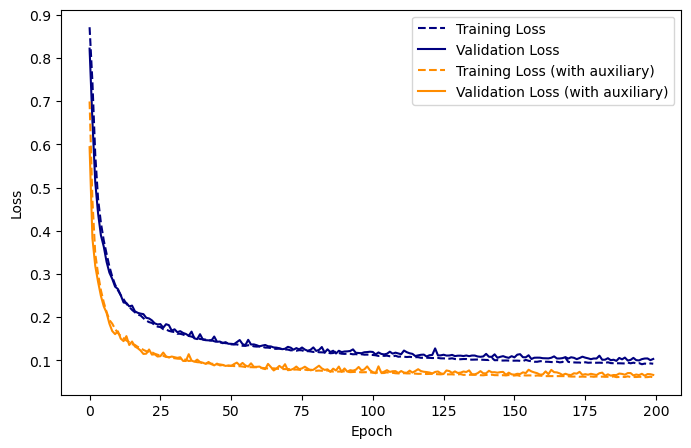

In [24]:
# Plot training and validation loss

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', color='navy', linestyle='--')
plt.plot(history.history['val_loss'], label='Validation Loss', color='navy')
plt.plot(history_aux.history['loss'], label='Training Loss (with auxiliary)', color='darkorange', linestyle='--')
plt.plot(history_aux.history['val_loss'], label='Validation Loss (with auxiliary)', color='darkorange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Predict the test data:

In [25]:
y_pred = model.predict(X_test)
y_pred_aux = model_aux.predict([X_test, X_aux_test])

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


**Scale values back:**

In [26]:
y_pred_physical = y_scaler.inverse_transform(y_pred)
y_pred_aux_physical = y_scaler.inverse_transform(y_pred_aux)
y_true = y_scaler.inverse_transform(y_test)

**Evaluate model:**

In [30]:
test_loss, test_mae = model.evaluate(X_test, y_test)
test_loss_aux, test_mae_aux = model_aux.evaluate([X_test, X_aux_test], y_test)

print('\n Spectrum-only model:')
print('Test loss:', test_loss)
print('Test MAE:', test_mae)

print('\n Spectrum + auxiliary model:')
print('Test loss:', test_loss_aux)
print('Test MAE:', test_mae_aux)

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1012 - mae: 0.2117
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0664 - mae: 0.1607

 Spectrum-only model:
Test loss: 0.10119077563285828
Test MAE: 0.21168972551822662

 Spectrum + auxiliary model:
Test loss: 0.06638995558023453
Test MAE: 0.16069777309894562


In [31]:
r2 = r2_score(y_true, y_pred_physical)
r2_aux = r2_score(y_true, y_pred_aux_physical)

print("Spectrum-only R²:", r2)
print("Spectrum + Auxiliary R²:", r2_aux)

Spectrum-only R²: 0.8997496015774974
Spectrum + Auxiliary R²: 0.9340008140861283


In [33]:
target_names = [
    'Planet radius',
    'Planet temperature',
    'log H2O',
    'log CO2',
    'log CO',
    'log CH4',
    'log NH3'
]

In [ ]:
for i, name in enumerate(target_names):

    r2 = r2_score(y_true[:, i], y_pred_physical[:, i])
    r2_aux = r2_score(y_true[:, i], y_pred_aux_physical[:, i])

    print(        
        f'{name:<20} '
        f'R² Spectrum only: {r2:6.3f}   '
        f'R² Spectrum + Auxiliary: {r2_aux:6.3f}'
    )

Planet radius        R² Spectrum only:  0.874   R² Spectrum + Auxiliary:  0.997
Planet temperature   R² Spectrum only:  0.943   R² Spectrum + Auxiliary:  0.986
log H2O              R² Spectrum only:  0.900   R² Spectrum + Auxiliary:  0.908
log CO2              R² Spectrum only:  0.939   R² Spectrum + Auxiliary:  0.954
log CO               R² Spectrum only:  0.823   R² Spectrum + Auxiliary:  0.856
log CH4              R² Spectrum only:  0.958   R² Spectrum + Auxiliary:  0.964
log NH3              R² Spectrum only:  0.861   R² Spectrum + Auxiliary:  0.875


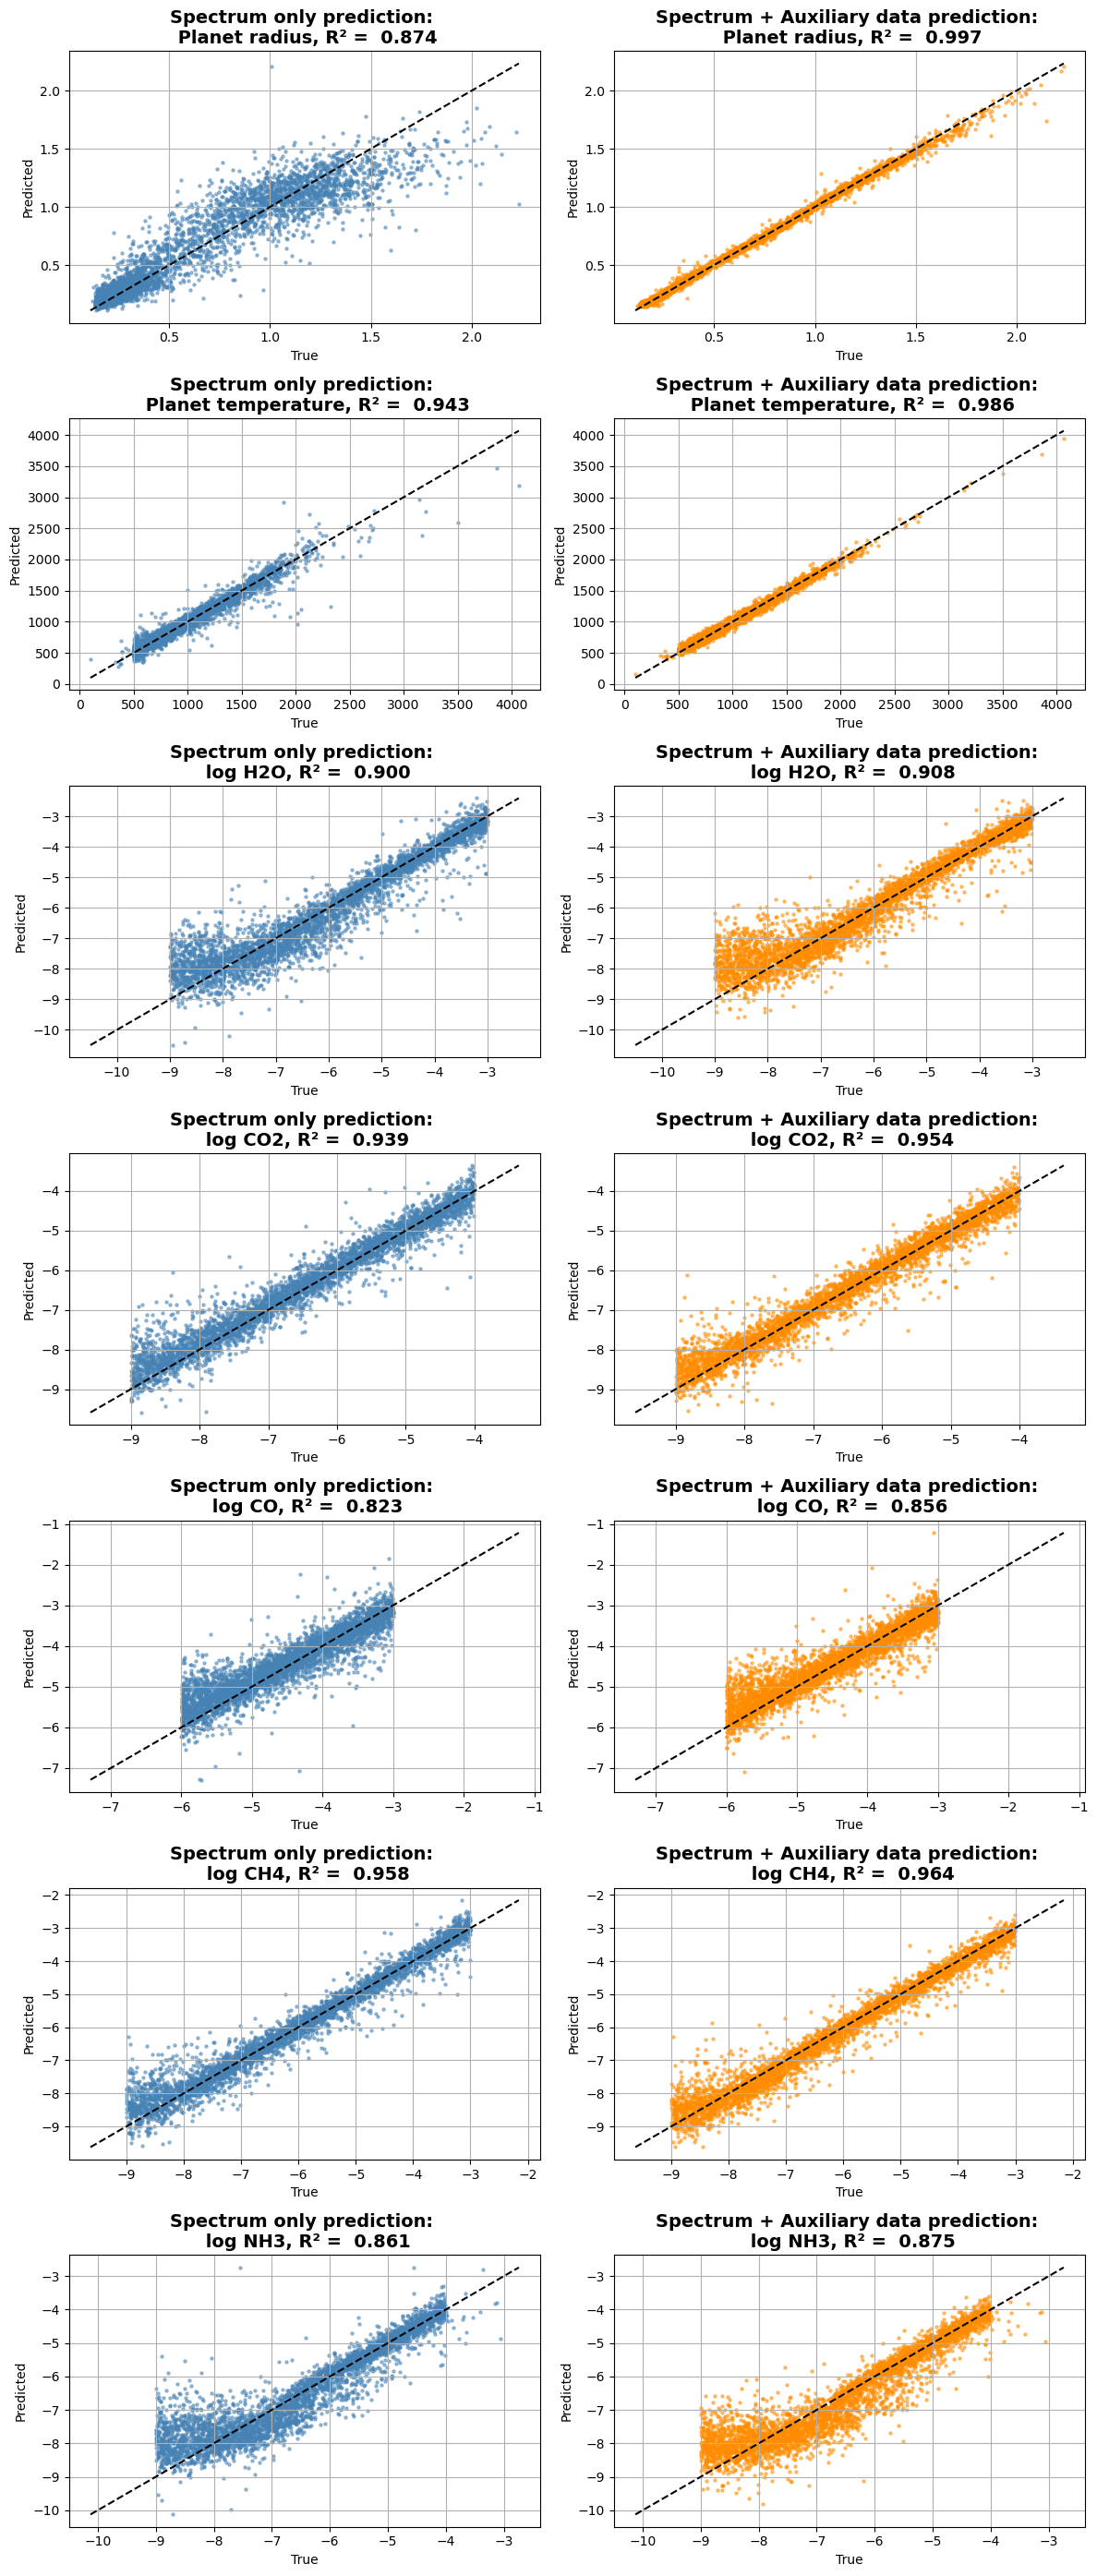

In [72]:
n_labels = len(target_names)
fig, axes = plt.subplots(n_labels, 2, figsize=(12, 4*n_labels))

for i, name in enumerate(target_names):

    min_val = min(y_true[:, i].min(), y_pred_physical[:, i].min(), y_pred_aux_physical[:, i].min())
    max_val = max(y_true[:, i].max(), y_pred_physical[:, i].max(), y_pred_aux_physical[:, i].max())

    r2 = r2_score(y_true[:, i], y_pred_physical[:, i])
    r2_aux = r2_score(y_true[:, i], y_pred_aux_physical[:, i])

    # Spectrum only
    axes[i, 0].scatter(y_true[:, i], y_pred_physical[:, i], alpha=0.5, s=5, color='steelblue')
    axes[i, 0].plot([min_val, max_val], [min_val, max_val], '--', color='black')
    axes[i, 0].set_title(f'Spectrum only prediction: \n {name}, R² = {r2:6.3f}', fontweight='bold', fontsize=14)
    axes[i, 0].set_xlabel('True')
    axes[i, 0].set_ylabel('Predicted')
    axes[i, 0].grid()

    # Spectrum + Auxiliary
    axes[i, 1].scatter(y_true[:, i], y_pred_aux_physical[:, i], alpha=0.5, s=5, color='darkorange')
    axes[i, 1].plot([min_val, max_val], [min_val, max_val], '--', color='black')
    axes[i, 1].set_title(f'Spectrum + Auxiliary data prediction: \n {name}, R² = {r2_aux:6.3f}', fontweight='bold', fontsize=14)
    axes[i, 1].set_xlabel('True')
    axes[i, 1].set_ylabel('Predicted')
    axes[i, 1].grid()

plt.tight_layout()